In [15]:
# 🔧 DIAGNÓSTICO DE ERRO CUDA - Execute antes de treinar
import torch
import torch.cuda as cuda

print("="*80)
print("📊 DIAGNÓSTICO DO SISTEMA GPU")
print("="*80)

# Verificar GPU
print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"GPU encontrada: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Nenhuma'}")

if torch.cuda.is_available():
    # Limpar cache antes de começar
    print("\n🧹 Limpando cache de GPU...")
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # Informações de memória
    props = torch.cuda.get_device_properties(0)
    total_memory = props.total_memory / 1e9
    print(f"Memória total da GPU: {total_memory:.2f} GB")

    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f"Memória alocada: {allocated:.2f} GB")
    print(f"Memória reservada: {reserved:.2f} GB")
    print(f"Memória livre: {(total_memory - reserved):.2f} GB")

    # Verificar compatibilidade
    print(f"\nVersão CUDA: {torch.version.cuda}")
    print(f"Versão cuDNN: {torch.backends.cudnn.version()}")
    print(f"cuDNN habilitado: {torch.backends.cudnn.enabled}")

else:
    print("⚠️  CUDA não disponível! Usando CPU (muito lento).")

print("="*80 + "\n")

📊 DIAGNÓSTICO DO SISTEMA GPU
CUDA disponível: True
GPU encontrada: NVIDIA GeForce RTX 4060

🧹 Limpando cache de GPU...
Memória total da GPU: 8.18 GB
Memória alocada: 0.00 GB
Memória reservada: 0.00 GB
Memória livre: 8.18 GB

Versão CUDA: 12.8
Versão cuDNN: 91002
cuDNN habilitado: True



In [16]:
import pandas as pd
from PIL import Image, ImageChops
import numpy as np
import torch
from sklearn.model_selection import KFold
from torch.utils.data import  DataLoader, TensorDataset, Dataset
from torch import nn
import timm
from tqdm.notebook import tqdm
import torch.optim as optim
import os

In [ ]:

FILE_PATH = 'data_balanced_AFIB_OTHERS.csv'

print("Iniciando o programa...")
print("Parametros de Execucao:")
folds = 5
epochs = 30
BATCH_SIZE = 64  # ✅ REDUZIDO de 64 para 32 (evita erro CUDA)
N_samples = 4514
flg_salvar_modelos = True
path = 'data/'
path_out = 'data_aug/'

print(f"  Numero de folds para K-Fold Cross Validation: {folds}")

print(f"  Tamanho do batch para treinamento: {BATCH_SIZE}")

print(f"  Numero de epocas para treinamento: {epochs}")
dataset_aug = pd.DataFrame(columns=['path', 'label'])


Iniciando o programa...
Parametros de Execucao:
  Numero de folds para K-Fold Cross Validation: 2
  Tamanho do batch para treinamento: 64
  Numero de epocas para treinamento: 30


In [18]:
def numpy_to_pil(numpy_array):
    # Verifica se o array tem a forma correta (C, H, W)
   # if numpy_array.shape[0] != 3:
     #   raise ValueError("O array deve ter a forma (3, H, W) para ser convertido em imagem PIL.")

    #print(numpy_array.shape)
    #print(numpy_array.dtype)
    img_pil = Image.fromarray(numpy_array.transpose(1, 2, 0))  # Converte de (C, H, W) para (H, W, C)
    return (img_pil)

    return pil_image

In [19]:
from PIL import Image, ImageChops
import numpy as np
import os
import shutil
import io
from pathlib import Path
def treat_image_PIL(img_path, type_return=2):
    ''''
    Input: Img_path, type return.

    Img_path: path da imagem em formato png, img...
    type_return: 1-> retorno como PIL.
                2 ou sem type_return -> retorno como numpy array tipo uint8

    Output:
    '''
    im = Image.open(path+img_path)

    # Size of the image in pixels (size of original image)
    # (This is not mandatory)
    width, height = im.size

    rgb =Image.Image.split(im)

    data =rgb
    b= data[0]
    g= data[1]
    r= data[2]
    #img_out = b+g+.5*r
    #img_out_2 = img_out[500:1600, 50:2100]

    newsize = (256, 256)
   # im3 =ImageChops.subtract(mask,b, scale=1.0, offset=0)

    b1 = b.crop((120,500,2100,1600))
    g1 = g.crop((120,500,2100,1600))
    r1 = r.crop((120,500,2100,1600))
    im1 = b1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    im2 = g1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    im3 = r1.resize(newsize, Image.Resampling.LANCZOS).convert('L')
    if type_return ==1:
        return Image.merge("RGB",(im1,im2,im3))
    elif type_return ==2:

        return np.array(im1,dtype=np.uint8)
    elif type_return ==3:

        return np.array([im1,im2,im3],dtype=np.uint8)
    elif type_return ==4:

        return np.array(im3,dtype=np.uint8)

def save_file_to_dir(file_obj, directory, filename):
    """
    Save a file to `directory` with the given `filename`.

    Parameters
    - file_obj: a PIL Image, a filesystem path (str or Path) to an existing file,
                bytes/bytearray, or a file-like object with a .read() method.
    - directory: target directory where the file will be saved.
    - filename: the name to use for the saved file (including extension if desired).

    Returns
    - full path (str) to the saved file.

    Raises
    - FileNotFoundError if a provided source path does not exist.
    - ValueError if the provided file_obj type is unsupported.
    """
    os.makedirs(directory, exist_ok=True)
    dest = os.path.join(directory, filename)

    # PIL Image
    if isinstance(file_obj, Image.Image):
        file_obj.save(dest)
        return dest

    # Path-like or string pointing to an existing file
    if isinstance(file_obj, (str, Path)):
        src = str(file_obj)
        if os.path.exists(src):
            shutil.copy(src, dest)
            return dest
        raise FileNotFoundError(f"Source path not found: {src}")

    # File-like object
    if hasattr(file_obj, "read"):
        data = file_obj.read()
        # If read() returned bytes -> try open as image, otherwise write raw
        if isinstance(data, (bytes, bytearray)):
            try:
                img = Image.open(io.BytesIO(data))
                img.save(dest)
                return dest
            except Exception:
                with open(dest, "wb") as f:
                    f.write(data)
                return dest
        else:
            # assume text
            with open(dest, "w", encoding="utf-8") as f:
                f.write(data)
            return dest

    # Raw bytes
    if isinstance(file_obj, (bytes, bytearray)):
        try:
            img = Image.open(io.BytesIO(file_obj))
            img.save(dest)
            return dest
        except Exception:
            with open(dest, "wb") as f:
                f.write(file_obj)
            return dest

    raise ValueError("file_obj must be a PIL.Image, path string/Path, bytes or file-like object")

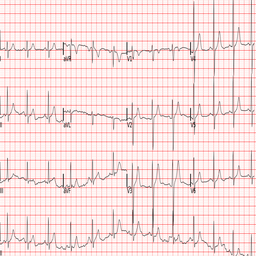

(3, 256, 256)
uint8


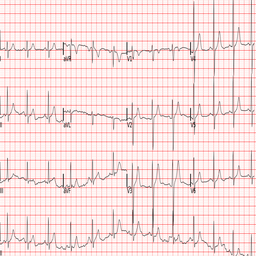

In [20]:
## Exemplo de uso de resize de imagem
image  = treat_image_PIL('00004_lr-0.png',1)
display(image)

## treat image pil as array and return to Image PIL and display
img_array = treat_image_PIL('00004_lr-0.png',3)
print(img_array.shape)
print(img_array.dtype)
img_pil = Image.fromarray(img_array.transpose(1, 2, 0))  # (3, 256, 256) → (256, 256, 3)
display(img_pil)

In [31]:
## Data augumentation
# Image Classification
import torch
from torchvision.transforms import v2
transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(30),
    v2.GaussianBlur(3)
  # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
def data_aug(img_input, n_replicas, img_out_dict, name_file, label):
  '''

  '''
  H, W = 32, 32
  dataset_aug = pd.DataFrame(columns=['path', 'label'])
  #display(img_array)
  name_file = name_file.split('.png')[0]

  for i in range(n_replicas):
    img = transforms(img_input)
    #display(img)
    ## write new images.
    img.save(f"{img_out_dict}/{name_file}_{i}.png")
    dataset_aug = pd.concat([dataset_aug, pd.DataFrame({'path': f"{img_out_dict}/{name_file}_{i}.png", 'label': label}, index=[0])], ignore_index=True)
  return dataset_aug

In [22]:
## Funções Otimizadas para Leitura de CSV e Carregamento de Imagens

import os
import psutil
from pathlib import Path

def explore_csv(csv_path, max_rows=5):
    """
    Explora arquivo CSV fornecendo informações detalhadas.

    Parâmetros:
        csv_path (str): Caminho do arquivo CSV
        max_rows (int): Número de linhas para exibir

    Retorna:
        pd.DataFrame: Dados carregados
    """
    print("="*80)
    print("📋 EXPLORAÇÃO DO ARQUIVO CSV")
    print("="*80)

    # Verificar se arquivo existe
    if not os.path.exists(csv_path):
        print(f"❌ ERRO: Arquivo não encontrado: {csv_path}")
        return None

    print(f"✓ Arquivo encontrado: {csv_path}")
    print(f"  Tamanho do arquivo: {os.path.getsize(csv_path) / (1024*1024):.2f} MB")

    try:
        # Ler CSV
        print("\n📖 Lendo arquivo CSV...")
        data = pd.read_csv(csv_path)

        print(f"✓ CSV lido com sucesso!")
        print(f"  Shape: {data.shape} (linhas, colunas)")
        print(f"  Colunas: {list(data.columns)}")
        print(f"  Tipos de dados:\n{data.dtypes}\n")

        # Verificar valores nulos
        print("📊 Valores Nulos:")
        null_counts = data.isnull().sum()
        if null_counts.sum() == 0:
            print("  ✓ Nenhum valor nulo encontrado!")
        else:
            print(f"  ⚠ Valores nulos encontrados:\n{null_counts}\n")

        # Primeiras linhas
        print(f"📄 Primeiras {max_rows} linhas:")
        print(data.head(max_rows).to_string())

        # Estatísticas
        print(f"\n📈 Estatísticas básicas:")
        print(f"  Total de amostras: {len(data)}")
        if data.shape[1] >= 2:
            label_col = data.columns[1]
            print(f"  Distribuição de labels ({label_col}):")
            print(data[label_col].value_counts().to_string())

        print("="*80)
        return data

    except Exception as e:
        print(f"❌ ERRO ao ler CSV: {e}")
        return None


def validate_and_load_images(data, image_path_prefix, n_samples=None, max_errors=10, type_return_img = 3):
    """
    Valida e carrega imagens com tratamento robusto de erros.

    Parâmetros:
        data (pd.DataFrame): DataFrame com caminhos das imagens
        image_path_prefix (str): Prefixo do caminho das imagens
        n_samples (int): Número de amostras a carregar (None = todas)
        max_errors (int): Máximo de erros antes de parar

    Retorna:
        tuple: (img_dataset, data_valid, error_count)
    """
    print("\n" + "="*80)
    print("🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS")
    print("="*80)

    # Preparar dados
    if n_samples is not None:
        data_sample = data.sample(n=min(n_samples, len(data)), random_state=42).reset_index(drop=True)
    else:
        data_sample = data.reset_index(drop=True)

    print(f"\n📌 Configuração:")
    print(f"  Amostras a processar: {len(data_sample)}")
    print(f"  Prefixo de caminho: {image_path_prefix}")
    print(f"  Máximo de erros permitidos: {max_errors}")

    # Verificar memória disponível
    memory_info = psutil.virtual_memory()
    print(f"\n💾 Memória disponível: {memory_info.available / (1024**3):.2f} GB")
    estimated_memory = (len(data_sample) * 3 * 256 * 256 * 1) / (1024**3)
    print(f"  Memória estimada para imagens: {estimated_memory:.2f} GB")

    if estimated_memory > memory_info.available * 0.8:
        print(f"  ⚠ AVISO: Uso de memória pode ser alto!")

    # Preparar array
    img_dataset = np.zeros((len(data_sample),3,256, 256), dtype=np.uint8)
    error_indices = []
    error_count = 0

    print(f"\n🔄 Carregando imagens...")

    for idx, row in tqdm(data_sample.iterrows(), total=len(data_sample), desc='Carregando imagens'):
        try:
            img_path = row.iloc[0]  # Primeira coluna = caminho
            full_path = os.path.join(image_path_prefix, img_path)

            # Verificar se arquivo existe
            if not os.path.exists(full_path):
                raise FileNotFoundError(f"Imagem não encontrada: {full_path}")

            # Carregar imagem
            img = treat_image_PIL(img_path, type_return=type_return_img)

            img_dataset[idx] = img

        except Exception as e:
            error_count += 1
            error_indices.append(idx)

            if error_count == 1:
                print(f"\n⚠ Erros encontrados durante carregamento:")

            print(f"  Erro na amostra {idx}: {type(e).__name__}: {str(e)[:60]}")

            if error_count >= max_errors:
                print(f"\n❌ Máximo de {max_errors} erros atingido. Parando...")
                break

    # Remover amostras com erro
    if error_indices:
        print(f"\n🧹 Removendo {len(error_indices)} amostras com erro...")
        valid_indices = [i for i in range(len(data_sample)) if i not in error_indices]
        img_dataset = img_dataset[valid_indices]
        data_sample = data_sample.iloc[valid_indices].reset_index(drop=True)

    print("\n✅ Carregamento concluído!")
    print(f"  Imagens carregadas com sucesso: {len(img_dataset)}")
    print(f"  Imagens com erro: {error_count}")
    print(f"  Shape final: {img_dataset.shape}")
    print("="*80)

    return img_dataset, data_sample, error_count


def get_image_statistics(img_dataset):
    """Calcula estatísticas das imagens carregadas."""
    print("\n" + "="*80)
    print("📊 ESTATÍSTICAS DAS IMAGENS")
    print("="*80)

    print(f"Shape: {img_dataset.shape}")
    print(f"Tipo de dado: {img_dataset.dtype}")
    print(f"Min: {img_dataset.min()}")
    print(f"Max: {img_dataset.max()}")
    print(f"Média: {img_dataset.mean():.2f}")
    print(f"Std: {img_dataset.std():.2f}")
    print(f"Memória total: {img_dataset.nbytes / (1024**2):.2f} MB")
    print("="*80)


In [23]:
print(f"Leitura e carregamento otimizado do arquivo '{FILE_PATH}'...\n")

# 1️⃣ EXPLORAR CSV PRIMEIRO
data = explore_csv(FILE_PATH, max_rows=10)

if data is None:
    print("❌ Não foi possível continuar. Verifique o arquivo CSV.")
else:
    # 2️⃣ RENOMEAR COLUNAS PARA PADRONIZAÇÃO
    print("\n🏷️  Padronizando nomes de colunas...")
    if data.shape[1] >= 2:
        data.rename(columns={data.columns[0]: 'path', data.columns[1]: 'label'}, inplace=True)
        print(f"✓ Colunas renomeadas: {list(data.columns[:2])}\n")

    # 3️⃣ CARREGAR IMAGENS COM VALIDAÇÃO
    img_dataset, data, error_count = validate_and_load_images(
        data=data,
        image_path_prefix=path,  # path definido anteriormente
        n_samples=N_samples,
        max_errors=10,
        type_return_img = 3
    )

    # 4️⃣ ESTATÍSTICAS DAS IMAGENS
    get_image_statistics(img_dataset)

    # 5️⃣ RESUMO FINAL
    print("\n" + "="*80)
    print("✅ RESUMO FINAL DO CARREGAMENTO")
    print("="*80)
    print(f"Arquivo CSV: {FILE_PATH}")
    print(f"Total de amostras: {len(data)}")
    print(f"Shape de imagens: {img_dataset.shape}")
    print(f"Distribuição de labels:")
    print(data['label'].value_counts().to_string())
    print("="*80 + "\n")


Leitura e carregamento otimizado do arquivo 'data_balanced_AFIB_OTHERS.csv'...

📋 EXPLORAÇÃO DO ARQUIVO CSV
✓ Arquivo encontrado: data_balanced_AFIB_OTHERS.csv
  Tamanho do arquivo: 0.07 MB

📖 Lendo arquivo CSV...
✓ CSV lido com sucesso!
  Shape: (4514, 2) (linhas, colunas)
  Colunas: ['path', 'label']
  Tipos de dados:
path       str
label    int64
dtype: object

📊 Valores Nulos:
  ✓ Nenhum valor nulo encontrado!
📄 Primeiras 10 linhas:
             path  label
0  15857_lr-0.png      0
1  15824_lr-0.png      1
2  21151_lr-0.png      0
3  00703_lr-0.png      1
4  15201_lr-0.png      0
5  12649_lr-0.png      0
6  03548_lr-0.png      1
7  03358_lr-0.png      0
8  12522_lr-0.png      0
9  04591_lr-0.png      0

📈 Estatísticas básicas:
  Total de amostras: 4514
  Distribuição de labels (label):
label
0    3000
1    1514

🏷️  Padronizando nomes de colunas...
✓ Colunas renomeadas: ['path', 'label']


🖼️  VALIDAÇÃO E CARREGAMENTO DE IMAGENS

📌 Configuração:
  Amostras a processar: 4514
  Prefi

Carregando imagens:   0%|          | 0/4514 [00:00<?, ?it/s]


✅ Carregamento concluído!
  Imagens carregadas com sucesso: 4514
  Imagens com erro: 0
  Shape final: (4514, 3, 256, 256)

📊 ESTATÍSTICAS DAS IMAGENS
Shape: (4514, 3, 256, 256)
Tipo de dado: uint8
Min: 0
Max: 255
Média: 233.50
Std: 28.98
Memória total: 846.38 MB

✅ RESUMO FINAL DO CARREGAMENTO
Arquivo CSV: data_balanced_AFIB_OTHERS.csv
Total de amostras: 4514
Shape de imagens: (4514, 3, 256, 256)
Distribuição de labels:
label
0    3000
1    1514



In [24]:
data.iloc[0]['path']

'10730_lr-0.png'

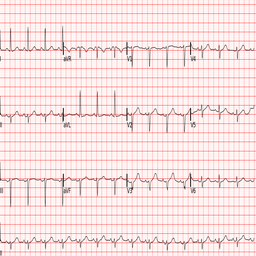

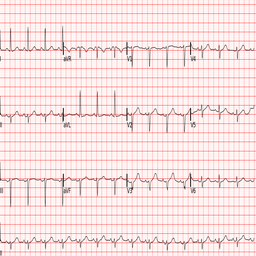

####################################


In [25]:
for index in range(0,1):
  caminho =  data.iloc[index]['path']
  ## Exemplo de uso de resize de imagem
  image  = treat_image_PIL(caminho,1)
  display(image)

  ## treat image pil as array and return to Image PIL and display

  display(numpy_to_pil(img_dataset[index]))
  print("####################################")

In [26]:
 data

,path,label
0,10730_lr-0.png,0
1,07012_lr-0.png,1
2,11081_lr-0.png,0
3,07030_lr-0.png,0
4,20661_lr-0.png,1
...,...,...
4509,15855_lr-0.png,0
4510,16069_lr-0.png,0
4511,21569_lr-0.png,0
4512,18078_lr-0.png,0


In [32]:
numpy_to_pil(img_dataset[0])

## Data augumentation_generation
dataset_aug = pd.DataFrame(columns=['path', 'label'])
for i  in range(len(img_dataset)) :
  if (data.iloc[i]['label'] == 1):
    dataset_aug = pd.concat([dataset_aug, data_aug(numpy_to_pil(img_dataset[i]), 2,"data_aug_AFIB",name_file = data.iloc[i]['path'], label = data.iloc[i]['label'])], ignore_index=True)

dataset_aug.to_csv('dataset_aug.csv', index=False)

In [33]:
leitura = pd.read_csv('dataset_aug.csv')

In [34]:
leitura.head()

,path,label
0,data_aug_AFIB/07012_lr-0_0.png,1
1,data_aug_AFIB/07012_lr-0_1.png,1
2,data_aug_AFIB/20661_lr-0_0.png,1
3,data_aug_AFIB/20661_lr-0_1.png,1
4,data_aug_AFIB/10927_lr-0_0.png,1
